
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

## Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



Primeras 5 filas del dataframe:
  especie       isla  longitud_pico (mm)  profundidad_pico (mm)  \
0  Adelie  Torgersen                39.1                   18.7   
1  Adelie  Torgersen                39.5                   17.4   
2  Adelie  Torgersen                40.3                   18.0   
3  Adelie  Torgersen                36.7                   19.3   
4  Adelie  Torgersen                39.3                   20.6   

   longitud_aleta (mm)  masa_corporal (g)  genero  
0                181.0             3750.0    Male  
1                186.0             3800.0  Female  
2                195.0             3250.0  Female  
3                193.0             3450.0  Female  
4                190.0             3650.0    Male   

1) Profundidad de pico en la isla Torgersen:
   Mínima: 15.9 mm
   Máxima: 21.5 mm

2) Pingüino con mayor masa corporal:
   Isla:   Biscoe
   Especie:Gentoo
   Género: Male
   Masa:   6300.0 g

3) Masa corporal media de pingüinos macho que NO son Gent

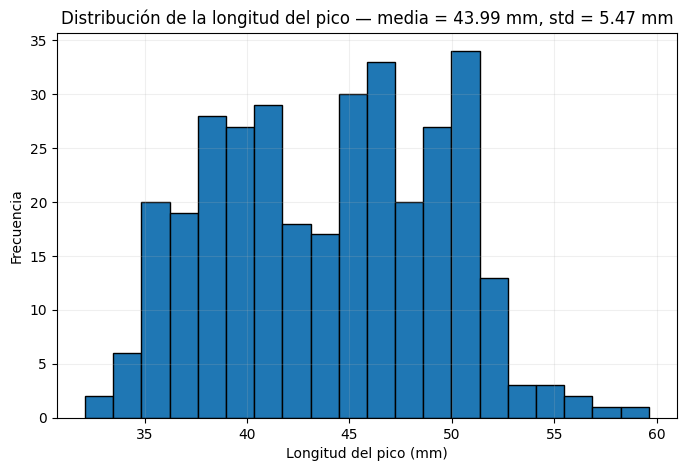

5) Frecuencias de islas presentes:
isla
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64 

   Frecuencias de especies presentes:
especie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64 



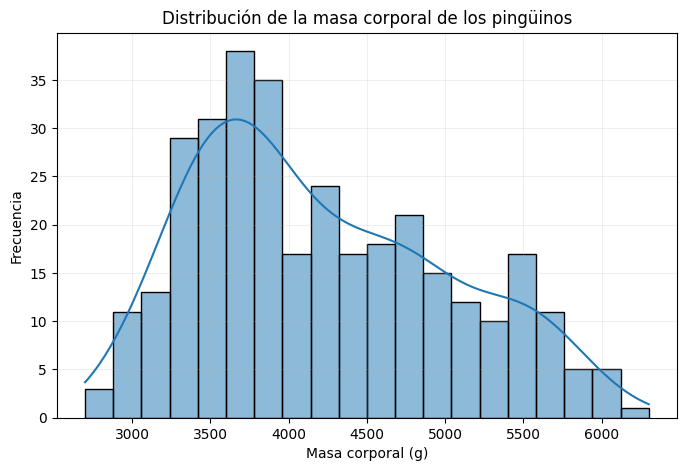

In [3]:
import matplotlib.pyplot as plt

# Convertir columnas numéricas a float para evitar problemas
for col in ["longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)"]:
    df[col] = pd.to_numeric(df[col])

# Mostrar primeras filas para verificar
print("Primeras 5 filas del dataframe:")
print(df.head(), "\n")

# 1)
torgersen_mask = df["isla"] == "Torgersen"
prof_torgersen = df.loc[torgersen_mask, "profundidad_pico (mm)"]
prof_min = prof_torgersen.min()
prof_max = prof_torgersen.max()
print("1) Profundidad de pico en la isla Torgersen:")
print(f"   Mínima: {prof_min} mm")
print(f"   Máxima: {prof_max} mm\n")

# 2)
idx_max_masa = df["masa_corporal (g)"].idxmax()   # índice del máximo
fila_max = df.loc[idx_max_masa]
print("2) Pingüino con mayor masa corporal:")
print(f"   Isla:   {fila_max['isla']}")
print(f"   Especie:{fila_max['especie']}")
print(f"   Género: {fila_max['genero']}")
print(f"   Masa:   {fila_max['masa_corporal (g)']} g\n")

# 3)
mask_male_non_gentoo = (df["genero"] == "Male") & (df["especie"] != "Gentoo")
masa_media = df.loc[mask_male_non_gentoo, "masa_corporal (g)"].mean()
print("3) Masa corporal media de pingüinos macho que NO son Gentoo:")
print(f"   Masa media: {masa_media:.2f} g\n")

# 4)
long_pico = df["longitud_pico (mm)"]
mean_long = long_pico.mean()
std_long = long_pico.std()

plt.figure(figsize=(8,5))
plt.hist(long_pico, bins=20, edgecolor='black')
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Frecuencia")
plt.title(f"Distribución de la longitud del pico — media = {mean_long:.2f} mm, std = {std_long:.2f} mm")
plt.grid(alpha=0.2)
plt.show()

# 5)
print("5) Frecuencias de islas presentes:")
print(df["isla"].value_counts(), "\n")

print("   Frecuencias de especies presentes:")
print(df["especie"].value_counts(), "\n")

# Grafica de la distribución de la masa corporal de los pingüinos
plt.figure(figsize=(8,5))
sns.histplot(df["masa_corporal (g)"], kde=True, bins=20)
plt.xlabel("Masa corporal (g)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la masa corporal de los pingüinos")
plt.grid(alpha=0.2)
plt.show()